<center> <h1>Final Project — Iron Will Sportsbook | DATA 5330</h1> </center>
<center> <h3> Will Braucher <h3> <center>

## DATA PREPERATION

In [187]:
import pandas as pd

df1 = pd.read_csv('spread_scores-2.csv')
df1 = df1[df1['schedule_season'] >= 2015]
df1['schedule_date'] = pd.to_datetime(df1['schedule_date'])
df1.head()

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail
3730,2015-09-10,2015,1,False,New England Patriots,28,21,Pittsburgh Steelers,NE,-7.0,51.0,Gillette Stadium,False,64.0,9.0,NaN,rain
3731,2015-09-13,2015,1,False,Arizona Cardinals,31,19,New Orleans Saints,ARI,-2.5,48.5,University of Phoenix Stadium,False,72.0,0.0,NaN,indoor
3732,2015-09-13,2015,1,False,Buffalo Bills,27,14,Indianapolis Colts,IND,-1.0,44.5,Ralph Wilson Stadium,False,53.0,7.0,NaN,NaN
3733,2015-09-13,2015,1,False,Chicago Bears,23,31,Green Bay Packers,GB,-6.5,48.5,Soldier Field,False,68.0,4.0,NaN,NaN
3734,2015-09-13,2015,1,False,Dallas Cowboys,27,26,New York Giants,DAL,-7.0,52.5,Cowboys Stadium,False,72.0,0.0,NaN,indoor


In [188]:
df2 = pd.read_csv('nfl_teams.csv')
df2.head()

,team_name,team_name_short,team_id,team_id_pfr,team_conference,team_division,team_conference_pre2002,team_division_pre2002
0,Arizona Cardinals,Cardinals,ARI,CRD,NFC,NFC West,NFC,NFC West
1,Atlanta Falcons,Falcons,ATL,ATL,NFC,NFC South,NFC,NFC West
2,Baltimore Colts,Colts,IND,CLT,AFC,NaN,AFC,AFC East
3,Baltimore Ravens,Ravens,BAL,RAV,AFC,AFC North,AFC,AFC Central
4,Boston Patriots,Patriots,NE,NWE,AFC,NaN,AFC,NaN


In [189]:
df3 = pd.read_csv('nfl_stadiums.csv')
df3.head()

,stadium_name,stadium_location,stadium_open,stadium_close,stadium_type,stadium_address,stadium_weather_station_code,stadium_weather_type,stadium_capacity,stadium_surface,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION
0,Acrisure Stadium,"Pittsburgh, PA",2001.0,NaN,outdoor,"100 Art Rooney Ave, Pittsburgh, PA 15212",15212,cold,"65,500",Grass,USW00094823,"PITTSBURGH ASOS, PA US",40.4846,-80.2144,366.7
1,Alamo Dome,"San Antonio, TX",NaN,NaN,indoor,"100 Montana St, San Antonio, TX 78203",78203,dome,72000,FieldTurf,NaN,NaN,NaN,NaN,NaN
2,Allegiant Stadium,"Paradise, NV",2020.0,NaN,indoor,NaN,NaN,dome,65000,Grass,NaN,NaN,NaN,NaN,NaN
3,Allianz Arena,"Munich, Germany",NaN,NaN,outdoor,NaN,NaN,moderate,"75,024",Grass,NaN,NaN,NaN,NaN,NaN
4,Alltel Stadium,"Jacksonville, FL",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [190]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   stadium_name                  118 non-null    object 
 1   stadium_location              116 non-null    object 
 2   stadium_open                  89 non-null     float64
 3   stadium_close                 41 non-null     float64
 4   stadium_type                  107 non-null    object 
 5   stadium_address               101 non-null    object 
 6   stadium_weather_station_code  100 non-null    object 
 7   stadium_weather_type          107 non-null    object 
 8   stadium_capacity              53 non-null     object 
 9   stadium_surface               67 non-null     object 
 10  STATION                       61 non-null     object 
 11  NAME                          61 non-null     object 
 12  LATITUDE                      61 non-null     float64
 13  LONGI

In [191]:
df_stadiums = df3.copy()

# I am doing a Numeric cleanup so I can match DB types and use it straight from my DF's in ingestion
df_stadiums['stadium_capacity'] = pd.to_numeric(
    df_stadiums['stadium_capacity'], errors='coerce'
)
df_stadiums['stadium_open'] = pd.to_numeric(
    df_stadiums['stadium_open'], errors='coerce'
)
df_stadiums['stadium_close'] = pd.to_numeric(
    df_stadiums['stadium_close'], errors='coerce'
)
df_stadiums['LATITUDE']  = pd.to_numeric(df_stadiums['LATITUDE'],  errors='coerce')
df_stadiums['LONGITUDE'] = pd.to_numeric(df_stadiums['LONGITUDE'], errors='coerce')
df_stadiums['ELEVATION'] = pd.to_numeric(df_stadiums['ELEVATION'], errors='coerce')

# There was an issue with the type so i changed them all to objects
df_stadiums = df_stadiums.astype(object).where(pd.notna(df_stadiums), None)

## CREATING THE TABLES

In [193]:
import pandas as pd
import numpy as np
import psycopg2
import warnings

warnings.filterwarnings("ignore")

conn = psycopg2.connect(
    database='iwdm',
    user='wbraucher',
    password='AWSViolet12',
    host='data5330.cr8c4uaqgpow.us-west-1.rds.amazonaws.com',
    port='5432'
)

cursor = conn.cursor()

In [194]:
# TABLE NFL_STADIUMS

query = '''CREATE TABLE IF NOT EXISTS nfl_stadiums (
    StadiumName     VARCHAR(100) PRIMARY KEY,
    StadiumLocation VARCHAR(50),
    StadiumOpen     SMALLINT,
    StadiumClose    SMALLINT,
    StadiumType     VARCHAR(15),
    StadiumAddress  VARCHAR(200),
    StadiumCapacity INTEGER,
    StadiumSurface  VARCHAR(40),
    Station         VARCHAR(15),
    StationName     VARCHAR(75),
    Latitude        NUMERIC(7,5),
    Longitude       NUMERIC(8,5),
    Elevation       NUMERIC(5,1)
);'''
cursor.execute(query)
conn.commit()

In [195]:
# TABLE NFL_TEAMS

query = '''CREATE TABLE IF NOT EXISTS nfl_teams (
    TeamName             VARCHAR(50)  PRIMARY KEY,
    TeamNameShort        VARCHAR(20)  NOT NULL,
    TeamID               VARCHAR(3)      NOT NULL,
    TeamIDPfr            CHAR(3)      NOT NULL,
    TeamConference       CHAR(3),
    TeamDivision         VARCHAR(15),
    TeamConferencePre2002 CHAR(3),
    TeamDivisionPre2002  VARCHAR(15)
);'''
cursor.execute(query)
conn.commit()


In [196]:
# TABLE INGESTION

query = '''CREATE TABLE IF NOT EXISTS Ingestion (
    IngestionID   SERIAL PRIMARY KEY,
    FileName      VARCHAR(50)  NOT NULL,
    FileType      VARCHAR(30)  NOT NULL,
    CompletedAt   TIMESTAMP 
);'''
cursor.execute(query)
conn.commit()


In [197]:
# TABLE EXCEPTION

query = '''CREATE TABLE IF NOT EXISTS exception (
    ExceptionID   SERIAL PRIMARY KEY,
    Record        TEXT         NOT NULL,
    FixTimeStamp  TIMESTAMP,
    Issue         TEXT,
    SourceTable   VARCHAR(25)
);'''
cursor.execute(query)
conn.commit()


In [198]:
# TABLE CUSTOMER_TABLE

query = '''CREATE TABLE IF NOT EXISTS customer_table (
    CustomerID      INTEGER      PRIMARY KEY,
    FirstName       VARCHAR(20)  NOT NULL,
    LastName        VARCHAR(20)  NOT NULL,
    CustomerAge     SMALLINT,
    CustomerType    VARCHAR(10),
    CustomerSince   SMALLINT,
    CustomerIncome  INTEGER,
    HouseholdSize   SMALLINT,
    ModeColor       VARCHAR(10)
);'''

cursor.execute(query)
conn.commit()

In [199]:
# TABLE GAME_INFO

query = '''CREATE TABLE IF NOT EXISTS game_info (
    GameID          VARCHAR(25) PRIMARY KEY,
    TeamHome        VARCHAR(50)  NOT NULL,
    TeamAway        VARCHAR(50)  NOT NULL,
    StadiumName     VARCHAR(50)  NOT NULL,
    ScheduleDate    DATE         NOT NULL,
    ScheduleSeason  SMALLINT     NOT NULL,
    ScheduleWeek    VARCHAR(15)  NOT NULL,
    SchedulePlayoff BOOLEAN,
    ScoreHome       SMALLINT,
    ScoreAway       SMALLINT,
    TeamFavoriteID  VARCHAR(4),
    SpreadFavorite  NUMERIC(3,1),
    OverUnderLine   NUMERIC(3,1),
    StadiumNeutral  BOOLEAN,
    WinnerLine      VARCHAR(4)   NOT NULL,
    WinnerOu        VARCHAR(5)   NOT NULL,
    CONSTRAINT fk_game_home_team
        FOREIGN KEY (TeamHome) REFERENCES nfl_teams(TeamName),
    CONSTRAINT fk_game_away_team
        FOREIGN KEY (TeamAway) REFERENCES nfl_teams(TeamName),
    CONSTRAINT fk_game_stadium
        FOREIGN KEY (StadiumName) REFERENCES nfl_stadiums(StadiumName)
);'''
cursor.execute(query)
conn.commit()


In [200]:
# TABLE BET_INFO

query = '''CREATE TABLE IF NOT EXISTS bet_info (
    BetID        SERIAL      PRIMARY KEY,
    CustomerID   INTEGER     NOT NULL,
    GameID       VARCHAR(25) NOT NULL,
    ExceptionID  INTEGER,
    IngestionID  INTEGER     NOT NULL,
    BetAmount    SMALLINT    NOT NULL,
    BetOn        VARCHAR(50),
    Commission   NUMERIC(6,2),
    BetResult    VARCHAR(5),
    CONSTRAINT fk_bet_customer
        FOREIGN KEY (CustomerID) REFERENCES customer_table(CustomerID),
    CONSTRAINT fk_bet_game
        FOREIGN KEY (GameID)     REFERENCES game_info(GameID),
    CONSTRAINT fk_bet_exception
        FOREIGN KEY (ExceptionID) REFERENCES exception(ExceptionID),
    CONSTRAINT fk_bet_ingestion
        FOREIGN KEY (IngestionID) REFERENCES Ingestion(IngestionID)
);'''
cursor.execute(query)
conn.commit()


In [201]:
# TABLE WEATHER

query = '''
CREATE TABLE IF NOT EXISTS weather (
    WeatherID                 SERIAL      PRIMARY KEY,
    GameID                    VARCHAR(25) NOT NULL UNIQUE,
    TemperatureF              SMALLINT,
    WindMph                   SMALLINT,
    HumidityPct               SMALLINT,
    StadiumWeatherStationCode VARCHAR(25),
    StadiumWeatherType        VARCHAR(15),
    WeatherDetail             VARCHAR(25),
    CONSTRAINT fk_weather_game
        FOREIGN KEY (GameID) REFERENCES game_info(GameID)
);
'''
cursor.execute(query)
conn.commit()


## INGESTION

#### NFL STADIUMS INGESTION INTO OUR STADIUM TABLE

In [238]:
from datetime import datetime

file_name = 'nfl_stadiums.csv'
ext = file_name.rsplit('.', 1)[-1].lower()
file_type = ext.upper()
now_ts = datetime.now()

# log ingestion
cursor.execute(f"""
    INSERT INTO Ingestion (FileName, FileType, CompletedAt)
    VALUES ('{file_name}', '{file_type}', NULL)
    RETURNING IngestionID;""")

ingestion_id = cursor.fetchone()[0]
conn.commit()

good_records = []
bad_records  = []

# function to log bad records to exception table
def log_exception(record_dict, issue_text, source_table='nfl_stadiums'):
    cols = list(record_dict.keys())
    vals = [str(record_dict.get(c, '')) for c in cols]
    record_str = " | ".join(vals)

    cursor.execute(f"""
        INSERT INTO exception (Record, Issue, SourceTable)
        VALUES ('{record_str}', '{str(issue_text)}', '{source_table}');""")

# loop through stadiums row by row
for idx in df_stadiums.index:

    try:
        # grab main variables
        stadium_name    = str(df_stadiums.at[idx, 'stadium_name']).strip() if df_stadiums.at[idx, 'stadium_name'] else None
        stadium_location = df_stadiums.at[idx, 'stadium_location']
        stadium_open     = df_stadiums.at[idx, 'stadium_open']
        stadium_close    = df_stadiums.at[idx, 'stadium_close']
        stadium_type     = df_stadiums.at[idx, 'stadium_type']
        stadium_address  = df_stadiums.at[idx, 'stadium_address']
        stadium_capacity = df_stadiums.at[idx, 'stadium_capacity']
        stadium_surface  = df_stadiums.at[idx, 'stadium_surface']
        station          = df_stadiums.at[idx, 'STATION']
        station_name     = df_stadiums.at[idx, 'NAME']
        latitude         = df_stadiums.at[idx, 'LATITUDE']
        longitude        = df_stadiums.at[idx, 'LONGITUDE']
        elevation        = df_stadiums.at[idx, 'ELEVATION']

        # skip if stadium_name missing
        if not stadium_name or stadium_name.lower() == 'nan':
            log_exception(df_stadiums.loc[idx].to_dict(), 'Missing StadiumName')
            bad_records.append(f"Row {idx}: missing StadiumName")
            continue

        # insert into nfl_stadiums
        cursor.execute("""INSERT INTO nfl_stadiums (
        StadiumName, StadiumLocation, StadiumOpen, StadiumClose,
        StadiumType, StadiumAddress, StadiumCapacity, StadiumSurface,
        Station, StationName, Latitude, Longitude, Elevation)
        
        VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s);""", 
        (
        stadium_name,
        stadium_location,
        stadium_open,
        stadium_close,
        stadium_type,
        stadium_address,
        stadium_capacity,
        stadium_surface,
        station,
        station_name,
        latitude,
        longitude,
        elevation
        ))


        # successful insert
        good_records.append(f"Inserted stadium: {stadium_name}")

    except Exception as e:
        conn.rollback()
        cursor = conn.cursor()

        print(f"Row {idx} ({stadium_name}) failed with error: {repr(e)}")

        # log exception
        log_exception(
            df_stadiums.loc[idx].to_dict(),
            f"Insertion error: {e}",
            'nfl_stadiums'
        )

        bad_records.append(f"Row {idx}: {stadium_name} failed")

        # commit exception log
        conn.commit()

# commit all inserts
conn.commit()

# finalize ingestion
cursor.execute(f"""
    UPDATE Ingestion 
    SET CompletedAt = '{datetime.now()}'
    WHERE IngestionID = {ingestion_id};""")

conn.commit()

# print results
print("\nBAD RECORDS:")
for x in bad_records:
    print(x)

print("\nGOOD RECORDS (first 10):")
for x in good_records[:10]:
    print(x)



BAD RECORDS:

GOOD RECORDS (first 10):
Inserted stadium: Acrisure Stadium
Inserted stadium: Alamo Dome
Inserted stadium: Allegiant Stadium
Inserted stadium: Allianz Arena
Inserted stadium: Alltel Stadium
Inserted stadium: Alumni Stadium
Inserted stadium: Anaheim Stadium
Inserted stadium: Arrowhead Stadium
Inserted stadium: AT&T Stadium
Inserted stadium: Atlanta-Fulton County Stadium


#### NFL TEAMS INGESTION INTO OUR TEAMS TABLE

In [240]:
# prepare teams dataframe
df_teams = df2.copy()
df_teams = df_teams.astype(object).where(pd.notna(df_teams), None)

file_name = 'nfl_teams.csv'
ext = file_name.rsplit('.', 1)[-1].lower()
file_type = ext.upper()
now_ts = datetime.now()

# log ingestion
cursor.execute(f"""
    INSERT INTO Ingestion (FileName, FileType, CompletedAt)
    VALUES ('{file_name}', '{file_type}', NULL)
    RETURNING IngestionID;""")

ingestion_id = cursor.fetchone()[0]
conn.commit()

good_records = []
bad_records  = []

# exception logger
def log_exception(record_dict, issue_text, source_table='nfl_teams'):
    cols = list(record_dict.keys())
    vals = [str(record_dict.get(c, '')) for c in cols]
    record_str = " | ".join(vals)

    cursor.execute(f"""
        INSERT INTO exception (Record, Issue, SourceTable)
        VALUES ('{record_str}', '{str(issue_text)}', '{source_table}');""")

# loop through teams row by row
for idx in df_teams.index:

    try:
        # pull main variables for clean insert
        team_id   = str(df_teams.at[idx, 'team_id']).strip() if df_teams.at[idx, 'team_id'] else None
        team_name = str(df_teams.at[idx, 'team_name']).strip() if df_teams.at[idx, 'team_name'] else None
        team_name_short = df_teams.at[idx, 'team_name_short']
        team_id_pfr = df_teams.at[idx, 'team_id_pfr']
        team_conf = df_teams.at[idx, 'team_conference']
        team_div = df_teams.at[idx, 'team_division']
        team_conf_pre = df_teams.at[idx, 'team_conference_pre2002']
        team_div_pre = df_teams.at[idx, 'team_division_pre2002']

        # validate required fields
        if not team_id or not team_name:
            log_exception(df_teams.loc[idx].to_dict(), 'Missing TeamID or TeamName')
            bad_records.append(f"Row {idx}: missing key fields")
            continue

        # insert into nfl_teams
        cursor.execute("""
        
        INSERT INTO nfl_teams 
        (TeamID, TeamNameShort, TeamName,
        TeamIDPfr, TeamConference, TeamDivision,
        TeamConferencePre2002, TeamDivisionPre2002)
    
        VALUES (%s,%s,%s,%s,%s,%s,%s,%s);""", 
        (
            team_id,
            team_name_short,
            team_name,
            team_id_pfr,
            team_conf,
            team_div,
            team_conf_pre,
            team_div_pre
        ))


        # successful insert
        good_records.append(f"Inserted team: {team_id} - {team_name}")

    except Exception as e:
        # rollback and log exception
        conn.rollback()
        cursor = conn.cursor()

        print(f"Row {idx} ({team_name}) failed with error: {repr(e)}")

        log_exception(
            df_teams.loc[idx].to_dict(),
            f"Insertion error: {e}",
            'nfl_teams'
        )

        bad_records.append(f"Row {idx}: {team_name} failed")

        # commit exception log
        conn.commit()

# commit all inserts
conn.commit()

# finalize ingestion
cursor.execute(f"""
    UPDATE Ingestion
    SET CompletedAt = '{datetime.now()}'
    WHERE IngestionID = {ingestion_id};""")
conn.commit()

# display results
print("\nBAD RECORDS:")
for x in bad_records:
    print(x)

print("\nGOOD RECORDS (first 10):")
for x in good_records[:10]:
    print(x)



BAD RECORDS:

GOOD RECORDS (first 10):
Inserted team: ARI - Arizona Cardinals
Inserted team: ATL - Atlanta Falcons
Inserted team: IND - Baltimore Colts
Inserted team: BAL - Baltimore Ravens
Inserted team: NE - Boston Patriots
Inserted team: BUF - Buffalo Bills
Inserted team: CAR - Carolina Panthers
Inserted team: CHI - Chicago Bears
Inserted team: CIN - Cincinnati Bengals
Inserted team: CLE - Cleveland Browns


#### CUSTOMER INFORMATION INGESTION INTO OUR CUSTOMER TABLE

In [242]:
import pymssql

conn = pymssql.connect(
    server='stairwaytoheaven.usu.edu',
    user='BLANK',             
    password='BLANK', 
    database='ironwill'            
)

cursor = conn.cursor()

query = """SELECT * FROM customer_table"""

df_customer_table = pd.read_sql(query, conn)
cursor.close()
conn.close()
df_customer_table.head()

,customer_id,customer_name,customer_age,customer_type,customer_since,customer_income,household_size,mode_color
0,1,Coraline Flores,23,online,2022,116000,1,red
1,2,Presley Ortiz,41,online,2021,111000,1,blue
2,3,Reid Knight,40,online,2023,55000,1,green
3,4,Clarissa Chandler,43,local,2023,32000,2,orange
4,5,Isaac Vaughn,23,phone,2023,46000,1,blue


In [251]:
# connect to postgres
conn = psycopg2.connect(
    database='iwdm',
    user='BLANK',
    password='BLANK',
    host='data5330.cr8c4uaqgpow.us-west-1.rds.amazonaws.com',
    port='5432'
)
cursor = conn.cursor()

# prepare customer dataframe
df_customers = df_customer_table.copy()
df_customers = df_customers.astype(object).where(pd.notna(df_customers), None)

# log ingestion
file_name = 'customer_table (SQL Server)'
file_type = 'DB'

cursor.execute(f"""
    INSERT INTO Ingestion (FileName, FileType, CompletedAt)
    VALUES ('{file_name}', '{file_type}', NULL)
    RETURNING IngestionID;""")

ingestion_id = cursor.fetchone()[0]
conn.commit()

good_records = []
bad_records  = []

# exception logger
def log_exception(record_dict, issue_text, source_table='customer_table'):
    cols = list(record_dict.keys())
    vals = [str(record_dict.get(c, '')) for c in cols]
    record_str  = " | ".join(vals)

    cursor.execute(f"""
        INSERT INTO exception (Record, Issue, SourceTable)
        VALUES ('{record_str}', '{str(issue_text)}', '{source_table}');""")

# loop through customers row by row
for idx in df_customers.index:

    try:
        unfixable = False

        # pull values for clean insert
        cust_id    = df_customers.at[idx, 'customer_id']
        cust_name  = df_customers.at[idx, 'customer_name']
        age        = df_customers.at[idx, 'customer_age']
        cust_type  = df_customers.at[idx, 'customer_type']
        since      = df_customers.at[idx, 'customer_since']
        income     = df_customers.at[idx, 'customer_income']
        household  = df_customers.at[idx, 'household_size']
        mode_color = df_customers.at[idx, 'mode_color']

        # validate name
        if not cust_name or ' ' not in str(cust_name):
            log_exception(df_customers.loc[idx].to_dict(), f"Missing or invalid name: {cust_name}")
            bad_records.append(f"Row {idx}: Invalid name → {cust_name}")
            continue

        first_name, last_name = str(cust_name).strip().split(" ", 1)

        # validate customer ID
        if cust_id is None:
            log_exception(df_customers.loc[idx].to_dict(), "Missing customer ID")
            bad_records.append(f"Row {idx}: Missing Customer ID")
            continue

        # insert into customer_table
        cursor.execute("""
        
        INSERT INTO customer_table 
        (CustomerID, FirstName, LastName,
        CustomerAge, CustomerType, CustomerSince,
        CustomerIncome, HouseholdSize, ModeColor)
        
        VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s);""", 
        (
        cust_id,
        first_name,
        last_name,
        age,
        cust_type,
        since,
        income,
        household,
        mode_color
        ))

        good_records.append(f"{first_name} {last_name}")

    except Exception as e:
        conn.rollback()
        cursor = conn.cursor()

        log_exception(
            df_customers.loc[idx].to_dict(),
            f"Insert error: {e}"
        )

        bad_records.append(f"Row {idx}: Insert failed")

# commit all inserts
conn.commit()

# finalize ingestion
cursor.execute(f"""
    UPDATE Ingestion
    SET CompletedAt = '{datetime.now()}'
    WHERE IngestionID = {ingestion_id};""")
conn.commit()

# print results
print("\nBAD RECORDS:")
for x in bad_records:
    print(x)

print("\nGOOD RECORDS (first 10):")
for x in good_records[:10]:
    print(x)



BAD RECORDS:

GOOD RECORDS (first 10):
Coraline Flores
Presley Ortiz
Reid Knight
Clarissa Chandler
Isaac Vaughn
Maleah James
Ada Weber
Winston Short
Jackson Marshall
Eleanor Daniel


#### SPREAD SCORE INGESTION INTO OUR GAME INFO TABLE

In [253]:
# just making copies so we don’t mess up the originals
df_games  = df1.copy()
df_teams  = df2.copy()
df_stadia = df3.copy()

# converting NaN to None so Postgres doesn’t freak out
df_games  = df_games.astype(object).where(pd.notna(df_games), None)
df_teams  = df_teams.astype(object).where(pd.notna(df_teams), None)
df_stadia = df_stadia.astype(object).where(pd.notna(df_stadia), None)

# mapping team names to team ids so we can quickly check them later
team_map    = df_teams.set_index('team_name')['team_id'].astype(str).to_dict()

# all stadium names as a clean set so lookups are easy
stadium_set = set(df_stadia['stadium_name'].astype(str).str.strip())


file_name = 'spread_scores_part2.csv'
file_type = file_name.rsplit('.', 1)[-1].upper()
now_ts    = datetime.now()


cursor.execute(
    f"""
    INSERT INTO ingestion (FileName, FileType, CompletedAt)
    VALUES ('{file_name}', '{file_type}', NULL)
    RETURNING IngestionID;""")

ingestion_id = cursor.fetchone()[0]
conn.commit()


# logs any bad rows into the exception table
def log_exception(idx, issue_text, source_table='game_info'):
    row_dict = df_games.loc[idx].to_dict()
    cols = list(row_dict.keys())
    vals = [str(row_dict.get(c, '')) for c in cols]
    record_str  = " | ".join(vals)

    cursor.execute(
        f"""
        INSERT INTO exception (Record, Issue, SourceTable)
        VALUES ('{record_str}', '{str(issue_text)}', '{source_table}');""")

# cleans up the weird playoff week names so they can be part of GameID
def normalize_week_for_id(week_raw):
    w = str(week_raw).strip()

    if w.isdigit():
        return f"{int(w):02d}"

    mapping = {
        'Wildcard':  '19',
        'Division':  '20',
        'Conference Championship': '21',
        'Superbowl': '22',
    }

    return mapping.get(w, w)


# figures out who covered the spread
def compute_winner_line(sh, sa):
    try:
        sh_i, sa_i = int(sh), int(sa)
    except:
        return None

    if sh_i > sa_i:
        return 'home'
    elif sa_i > sh_i:
        return 'away'
    else:
        return 'push'


# figures out if total score was over/under the posted line
def compute_winner_ou(sh, sa, ou):
    try:
        sh_i, sa_i = int(sh), int(sa)
        ou_f = float(ou)
    except:
        return None

    total = sh_i + sa_i

    if total > ou_f:
        return 'over'
    elif total < ou_f:
        return 'under'
    else:
        return 'push'


# cleaning team and stadium names so we don’t get false mismatches
df_games['team_home_clean'] = df_games['team_home'].astype(str).str.strip()
df_games['team_away_clean'] = df_games['team_away'].astype(str).str.strip()
df_games['stadium_clean']   = df_games['stadium'].astype(str).str.strip()

# checking which rows actually match the lookup tables
home_ok = df_games['team_home_clean'].isin(team_map)
away_ok = df_games['team_away_clean'].isin(team_map)
stadium_ok = df_games['stadium_clean'].isin(stadium_set)

bad_records  = []
good_records = []


# grabbing indexes of bad rows
bad_home_idx = df_games.index[~home_ok]
bad_away_idx = df_games.index[~away_ok]
bad_stad_idx = df_games.index[~stadium_ok]

# log any home team issues
for idx in bad_home_idx:
    log_exception(idx, f"Missing TeamID for home: {df_games.loc[idx,'team_home']}")
    bad_records.append(f"Row {idx}: bad home '{df_games.loc[idx,'team_home']}'")

# same thing but for away teams
for idx in bad_away_idx:
    log_exception(idx, f"Missing TeamID for away: {df_games.loc[idx,'team_away']}")
    bad_records.append(f"Row {idx}: bad away '{df_games.loc[idx,'team_away']}'")

# and same for stadium
for idx in bad_stad_idx:
    log_exception(idx, f"Missing Stadium: {df_games.loc[idx,'stadium']}")
    bad_records.append(f"Row {idx}: bad stadium '{df_games.loc[idx,'stadium']}'")

# only the rows that passed all checks
valid_mask = home_ok & away_ok & stadium_ok
df_valid = df_games.loc[valid_mask].copy()


# building GameID (basically a unique id for each matchup)
df_valid['GameID'] = (
    df_valid['schedule_season'].astype(int).astype(str) +
    df_valid['schedule_week'].apply(normalize_week_for_id) + '-' +
    df_valid['team_home_clean'].map(team_map) + '-' +
    df_valid['team_away_clean'].map(team_map)
)

# adding winner info to each valid row
df_valid['WinnerLine'] = df_valid.apply(
    lambda r: compute_winner_line(r['score_home'], r['score_away']),
    axis=1
)

df_valid['WinnerOu'] = df_valid.apply(
    lambda r: compute_winner_ou(r['score_home'], r['score_away'], r['over_under_line']),
    axis=1
)


for idx in df_valid.index:

    game_id = df_valid.loc[idx, 'GameID']
    team_home        = df_valid.loc[idx, "team_home_clean"]
    team_away        = df_valid.loc[idx, "team_away_clean"]
    stadium          = df_valid.loc[idx, "stadium_clean"]
    schedule_date    = df_valid.loc[idx, "schedule_date"]
    season           = df_valid.loc[idx, "schedule_season"]
    week_raw         = df_valid.loc[idx, "schedule_week"]
    week             = str(week_raw).strip() if week_raw is not None else None
    playoff          = df_valid.loc[idx, "schedule_playoff"]
    score_home       = df_valid.loc[idx, "score_home"]
    score_away       = df_valid.loc[idx, "score_away"]
    fav_id           = df_valid.loc[idx, "team_favorite_id"]
    spread           = df_valid.loc[idx, "spread_favorite"]
    ou_line          = df_valid.loc[idx, "over_under_line"]
    neutral          = df_valid.loc[idx, "stadium_neutral"]
    winner_line      = df_valid.loc[idx, "WinnerLine"]
    winner_ou        = df_valid.loc[idx, "WinnerOu"]
    
    try:
        cursor.execute("""
            
            INSERT INTO game_info 
            (GameID, TeamHome, TeamAway, StadiumName,
             ScheduleDate, ScheduleSeason, ScheduleWeek,
             SchedulePlayoff, ScoreHome, ScoreAway,
             TeamFavoriteID, SpreadFavorite, OverUnderLine,
             StadiumNeutral, WinnerLine, WinnerOu)
            
            VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s);""", 
            (
            game_id,
            team_home,
            team_away,
            stadium,
            schedule_date,
            season,
            week,
            playoff,
            score_home,
            score_away,
            fav_id,
            spread,
            ou_line,
            neutral,
            winner_line,
            winner_ou
            ))

        good_records.append(game_id)

    except Exception as e:
        conn.rollback()
        cursor = conn.cursor()
        log_exception(idx, f"Insertion error: {e}")
        bad_records.append(f"Row {idx}: insert failed ({repr(e)})")

    conn.commit()


cursor.execute(
    f"""
    UPDATE ingestion
    SET CompletedAt = '{datetime.now()}'
    WHERE IngestionID = {ingestion_id};""")

conn.commit()


print("\nBAD RECORDS:")
for x in bad_records:
    print(x)

print("\nGOOD RECORDS (first 10):")
for x in good_records[:10]:
    print(x)



BAD RECORDS:
Row 4804: bad stadium 'Dignity Health Sports Park'
Row 4838: bad stadium 'Dignity Health Sports Park'
Row 4867: bad stadium 'Dignity Health Sports Park'
Row 4883: bad stadium 'Dignity Health Sports Park'
Row 4926: bad stadium 'Dignity Health Sports Park'
Row 5014: bad stadium 'Dignity Health Sports Park'
Row 5030: bad stadium 'Dignity Health Sports Park'
Row 6033: bad stadium 'Frankfurt Stadium'
Row 6048: bad stadium 'Frankfurt Stadium'

GOOD RECORDS (first 10):
201501-NE-PIT
201501-ARI-NO
201501-BUF-IND
201501-CHI-GB
201501-DAL-NYG
201501-DEN-BAL
201501-HOU-KC
201501-JAX-CAR
201501-NYJ-CLE
201501-LVR-CIN


#### WEATHER INFORMATION INGESTION INTO OUR TEAMS TABLE

In [254]:
df_weather_games = df1.copy()
df_stadia = df3.copy()

# Convert NaNs to None for DB insert
df_weather_games = df_weather_games.astype(object).where(pd.notna(df_weather_games), None)
df_stadia = df_stadia.astype(object).where(pd.notna(df_stadia), None)

# create lookup for stadium weather info
stadium_weather_map = df_stadia.set_index('stadium_name')[
    ['stadium_weather_station_code', 'stadium_weather_type']
].to_dict('index')

# insert ingestion record
file_name = 'spread_scores_weather.csv'
file_type = file_name.rsplit('.', 1)[-1].upper()

cursor.execute(f"""
    INSERT INTO ingestion (FileName, FileType, CompletedAt)
    VALUES ('{file_name}', '{file_type}', NULL)
    RETURNING IngestionID;""")

ingestion_id = cursor.fetchone()[0]
conn.commit()

# exception logger
def log_exception(idx, issue_text, source_table='weather'):
    row_dict = df_weather_games.loc[idx].to_dict()
    cols     = list(row_dict.keys())
    vals     = [str(row_dict.get(c, '')) for c in cols]
    record_str  = " | ".join(vals)

    cursor.execute(f"""
        INSERT INTO exception (Record, Issue, SourceTable)
        VALUES ('{record_str}', '{str(issue_text)}', '{source_table}');""")

# clean team names
df_weather_games['team_home_clean'] = df_weather_games['team_home'].astype(str).str.strip()
df_weather_games['team_away_clean'] = df_weather_games['team_away'].astype(str).str.strip()

# create GameID
df_weather_games['GameID'] = (
    df_weather_games['schedule_season'].astype(int).astype(str) +
    df_weather_games['schedule_week'].apply(normalize_week_for_id) + '-' +
    df_weather_games['team_home_clean'].map(team_map).fillna('UNK').astype(str) + '-' +
    df_weather_games['team_away_clean'].map(team_map).fillna('UNK').astype(str)
)

# check stadiums
stadium_clean = df_weather_games['stadium'].astype(str).str.strip()
stadium_ok    = stadium_clean.isin(stadium_weather_map.keys())

bad_records  = []
good_records = []
total_rows   = len(df_weather_games)

# log rows with bad stadiums
bad_stad_idx = df_weather_games.index[~stadium_ok]
for idx in bad_stad_idx:
    log_exception(idx, f"Missing stadium weather mapping: {df_weather_games.loc[idx, 'stadium']}")
    bad_records.append(f"Row {idx}: bad stadium '{df_weather_games.loc[idx, 'stadium']}'")

# keep only valid rows
df_valid = df_weather_games.loc[stadium_ok].copy()

print(f"Total weather rows: {total_rows}")
print(f"Valid stadium rows: {len(df_valid)}")
print(f"Bad stadium rows: {len(bad_records)}")

# insert into weather table
for idx in df_valid.index:

    # grab variables for clean insert
    game_id      = df_valid.loc[idx, 'GameID']
    temp_f       = df_valid.loc[idx, 'weather_temperature']
    wind_mph     = df_valid.loc[idx, 'weather_wind_mph']
    humidity     = df_valid.loc[idx, 'weather_humidity']
    detail       = df_valid.loc[idx, 'weather_detail']
    stadium_name = df_valid.loc[idx, 'stadium']

    station_code = None
    station_type = None
    if stadium_name in stadium_weather_map:
        station_code = stadium_weather_map[stadium_name]['stadium_weather_station_code']
        station_type = stadium_weather_map[stadium_name]['stadium_weather_type']

    try:
        # make sure game exists
        cursor.execute("SELECT 1 FROM game_info WHERE GameID = %s;", (game_id,))
        if not cursor.fetchone():
            log_exception(idx, f"Missing GameID in game_info: {game_id}")
            bad_records.append(f"Row {idx}: missing GameID in game_info")
            continue

        # skip if already exists
        cursor.execute("SELECT 1 FROM weather WHERE GameID = %s;", (game_id,))
        if cursor.fetchone():
            bad_records.append(f"Row {idx}: already exists {game_id}")
            continue

        # insert row
        cursor.execute("""
        
        INSERT INTO weather 
        (GameID, TemperatureF, WindMph,
         HumidityPct, StadiumWeatherStationCode,
         StadiumWeatherType, WeatherDetail)
        
        VALUES (%s, %s, %s, %s, %s, %s, %s);""", 
        (
        game_id,
        temp_f,
        wind_mph,
        humidity,
        station_code,
        station_type,
        detail
        ))

        good_records.append(game_id)

    except Exception as e:
        conn.rollback()
        cursor = conn.cursor()
        log_exception(idx, f"Insertion error: {e}")
        bad_records.append(f"Row {idx}: insertion failed ({repr(e)})")
    finally:
        conn.commit()

# finalize ingestion
cursor.execute(f"""
    UPDATE ingestion
    SET CompletedAt = '{datetime.now()}'
    WHERE IngestionID = {ingestion_id};""")

conn.commit()

print("\nBAD RECORDS (first 10):")
for x in bad_records[:10]:
    print(x)

print("\nGOOD RECORDS (first 10):")
for x in good_records[:10]:
    print(x)


Total weather rows: 2458
Valid stadium rows: 2449
Bad stadium rows: 9

BAD RECORDS (first 10):
Row 4804: bad stadium 'Dignity Health Sports Park'
Row 4838: bad stadium 'Dignity Health Sports Park'
Row 4867: bad stadium 'Dignity Health Sports Park'
Row 4883: bad stadium 'Dignity Health Sports Park'
Row 4926: bad stadium 'Dignity Health Sports Park'
Row 5014: bad stadium 'Dignity Health Sports Park'
Row 5030: bad stadium 'Dignity Health Sports Park'
Row 6033: bad stadium 'Frankfurt Stadium'
Row 6048: bad stadium 'Frankfurt Stadium'

GOOD RECORDS (first 10):
201501-NE-PIT
201501-ARI-NO
201501-BUF-IND
201501-CHI-GB
201501-DAL-NYG
201501-DEN-BAL
201501-HOU-KC
201501-JAX-CAR
201501-NYJ-CLE
201501-LVR-CIN


#### BET INFORMATION INGESTION INTO OUR BETTING TABLE

In [263]:
mssql_conn = pymssql.connect(
    server='stairwaytoheaven.usu.edu',
    user='BLANK',
    password='BLANK',
    database='ironwill'
)
df_bet_log = pd.read_sql("SELECT * FROM betlog", mssql_conn)
mssql_conn.close()
df_bet_log.head()

,bet_id,customer_id,game_id,bet_amount,bet_on
0,1,1,202301-KC-DET,8500,Detroit Lions
1,2,7,202301-KC-DET,350,under
2,3,8,202301-KC-DET,10000,Kansas City Chiefs
3,4,23,202301-KC-DET,200,under
4,5,24,202301-KC-DET,400,over


In [288]:
conn = psycopg2.connect(
    database='iwdm',
    user='BLANK',
    password='BLANK',
    host='data5330.cr8c4uaqgpow.us-west-1.rds.amazonaws.com',
    port='5432'
)
cursor = conn.cursor()

# get existing GameIDs
cursor.execute("SELECT GameID FROM game_info;")
existing_games = {r[0] for r in cursor.fetchall()}

# create team map
team_map = df2.set_index('team_name')['team_id'].to_dict()

# get game info with team IDs
cursor.execute("""
    SELECT g.GameID,
           t_home.TeamID AS team_home_id,
           t_away.TeamID AS team_away_id,
           g.ScoreHome,
           g.ScoreAway,
           g.TeamFavoriteID,
           g.SpreadFavorite,
           g.OverUnderLine,
           g.WinnerLine
    FROM game_info g
    JOIN nfl_teams t_home ON g.TeamHome = t_home.TeamName
    JOIN nfl_teams t_away ON g.TeamAway = t_away.TeamName;
""")
game_rows = cursor.fetchall()
game_cols = [
    'game_id','team_home_id','team_away_id',
    'score_home','score_away',
    'team_favorite_id','spread_favorite',
    'over_under_line','winner_line'
]
df_game_info = pd.DataFrame(game_rows, columns=game_cols).set_index('game_id')

# helper to calculate commission
def calc_commission(amount):
    if amount is None:
        return None
    amt = float(amount)
    t1 = min(amt, 1000)
    t2 = min(max(amt - 1000, 0), 4000)
    t3 = max(amt - 5000, 0)
    return round(0.10*t1 + 0.08*t2 + 0.06*t3, 2)

# helper to determine bet result
def calc_team_result(df):
    margin = df['score_home'].astype(float) - df['score_away'].astype(float)
    fav_mask = (
        df['team_favorite_id'].notna() &
        (df['team_favorite_id'] != 'PICK') &
        (df['bet_on_id'] == df['team_favorite_id'])
    )
    fav_margin = margin.where(df['team_favorite_id'] == df['team_home_id'], -margin)
    spread = df['spread_favorite'].astype(float)

    df.loc[fav_mask & (fav_margin > spread), 'bet_result'] = 'win'
    df.loc[fav_mask & (fav_margin == spread), 'bet_result'] = 'push'
    df.loc[fav_mask & (fav_margin < spread), 'bet_result'] = 'loss'

    wl = df['winner_line'].astype(str).str.lower()
    df.loc[wl.eq('push'), 'bet_result'] = 'push'
    df.loc[(wl.eq('home')) & (df['bet_on_id'] == df['team_home_id']), 'bet_result'] = 'win'
    df.loc[(wl.eq('away')) & (df['bet_on_id'] == df['team_away_id']), 'bet_result'] = 'win'

    df.loc[df['bet_result'].isna(), 'bet_result'] = 'loss'
    return df

# prepare bet dataframe
df_bets = df_bet_log.copy()
df_bets = df_bets.astype(object).where(pd.notna(df_bets), None)

df_bets = df_bets.join(df_game_info, on='game_id', how='left')

df_bets['bet_on_id'] = df_bets['bet_on'].apply(
    lambda x: None if x is None or str(x).lower() in ('over','under')
    else team_map.get(str(x).strip())
)
df_bets['commission'] = df_bets['bet_amount'].apply(calc_commission)

# calculate over/under results
ou_mask = df_bets['bet_on'].astype(str).str.lower().isin(['over','under'])
totals  = df_bets['score_home'].astype(float) + df_bets['score_away'].astype(float)
ou_line = df_bets['over_under_line'].astype(float)

df_bets.loc[ou_mask & (totals > ou_line), 'bet_result']  = 'win'
df_bets.loc[ou_mask & (totals < ou_line), 'bet_result']  = 'loss'
df_bets.loc[ou_mask & (totals == ou_line), 'bet_result'] = 'push'

df_bets = calc_team_result(df_bets)

# insert ingestion record
file_name = 'betlog (SQL Server)'
file_type = 'DB'

cursor.execute(f"""
    INSERT INTO ingestion (FileName, FileType, CompletedAt)
    VALUES ('{file_name}', '{file_type}', NULL)
    RETURNING IngestionID;""")

ingestion_id = cursor.fetchone()[0]
conn.commit()

# exception logger
def log_exception_bet(idx, issue_text, source_table='bet_info'):
    row_dict = df_bets.loc[idx].to_dict()
    cols     = list(row_dict.keys())
    vals     = [str(row_dict.get(c, '')) for c in cols]
    record_str  = " | ".join(vals)

    cursor.execute(f"""
        INSERT INTO exception (Record, Issue, SourceTable)
        VALUES ('{record_str}','{str(issue_text)}','{source_table}'); """)

# validate rows
missing_game_mask = ~df_bets['game_id'].isin(existing_games)
missing_req_mask  = df_bets['customer_id'].isna() | df_bets['bet_amount'].isna()

bad_records  = []
good_records = []

for idx in df_bets.index[missing_game_mask | missing_req_mask]:
    if missing_game_mask.loc[idx]:
        log_exception_bet(idx, f"Missing GameID in game_info: {df_bets.loc[idx, 'game_id']}")
        bad_records.append(f"Row {idx}: missing GameID {df_bets.loc[idx, 'game_id']}")
    else:
        log_exception_bet(idx, "Missing customer_id or bet_amount")
        bad_records.append(f"Row {idx}: missing customer_id or bet_amount")

conn.commit()

df_valid = df_bets.loc[~(missing_game_mask | missing_req_mask)].copy()
total_rows = len(df_bets)

print(f"Total bets: {total_rows}")
print(f"Valid bets: {len(df_valid)}")
print(f"Bad bets: {len(bad_records)}")

# row-by-row insert
for idx in df_valid.index:
    customer_id = df_valid.loc[idx, 'customer_id']
    game_id     = df_valid.loc[idx, 'game_id']
    bet_amount  = df_valid.loc[idx, 'bet_amount']
    bet_on      = df_valid.loc[idx, 'bet_on']
    commission  = df_valid.loc[idx, 'commission']
    bet_result  = df_valid.loc[idx, 'bet_result']

    try:
        cursor.execute("""
            
            INSERT INTO bet_info 
            (CustomerID, GameID, ExceptionID,
             IngestionID, BetAmount, BetOn,
             Commission, BetResult)
            
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s);""", 
            (
            customer_id,
            game_id,
            None,
            ingestion_id,
            bet_amount,
            bet_on,
            commission,
            bet_result
            ))
        
        good_records.append(f"Bet idx {idx}: cust={customer_id}, game={game_id}")

    except Exception as e:
        conn.rollback()
        cursor = conn.cursor()
        log_exception_bet(idx, f"Insertion error: {e}")
        bad_records.append(f"Row {idx}: insertion failed ({repr(e)})")
    finally:
        conn.commit()

# finalize ingestion
cursor.execute(f"""
    UPDATE ingestion
    SET CompletedAt = '{datetime.now()}'
    WHERE IngestionID = {ingestion_id};""")

conn.commit()

print("\nBAD RECORDS (first 10):")
for x in bad_records[:10]:
    print(x)

print("\nGOOD RECORDS (first 10):")
for x in good_records[:10]:
    print(x)

Total bets: 126047
Valid bets: 109084
Bad bets: 16963

BAD RECORDS (first 10):
Row 2133: missing GameID 202301-DEN-LV
Row 2134: missing GameID 202301-DEN-LV
Row 2135: missing GameID 202301-DEN-LV
Row 2136: missing GameID 202301-DEN-LV
Row 2137: missing GameID 202301-DEN-LV
Row 2138: missing GameID 202301-DEN-LV
Row 2139: missing GameID 202301-DEN-LV
Row 2140: missing GameID 202301-DEN-LV
Row 2141: missing GameID 202301-DEN-LV
Row 2142: missing GameID 202301-DEN-LV

GOOD RECORDS (first 10):
Bet idx 0: cust=1, game=202301-KC-DET
Bet idx 1: cust=7, game=202301-KC-DET
Bet idx 2: cust=8, game=202301-KC-DET
Bet idx 3: cust=23, game=202301-KC-DET
Bet idx 4: cust=24, game=202301-KC-DET
Bet idx 5: cust=27, game=202301-KC-DET
Bet idx 6: cust=29, game=202301-KC-DET
Bet idx 7: cust=30, game=202301-KC-DET
Bet idx 8: cust=32, game=202301-KC-DET
Bet idx 9: cust=43, game=202301-KC-DET


## FIXING ISSUES FROM THE EXCEPTION TABLE

In [290]:
conn = psycopg2.connect(
    database='iwdm',
    user='wbraucher',
    password='AWSViolet12',
    host='data5330.cr8c4uaqgpow.us-west-1.rds.amazonaws.com',
    port='5432'
)
cursor = conn.cursor()

query = """SELECT ExceptionID, Record, Issue
           FROM exception
           WHERE SourceTable = 'bet_info'
           AND Issue LIKE 'Missing GameID in game_info:%';"""

df_fixing_exceptions = pd.read_sql(query,conn)
print(df_fixing_exceptions.head())

   exceptionid                                             record  \
0        17859  2971 | 1838 | 202301-IND-JAC | 175 | over | na...   
1        17860  2972 | 1842 | 202301-IND-JAC | 150 | Jacksonvi...   
2        17861  2973 | 1851 | 202301-IND-JAC | 100 | over | na...   
3        17862  2974 | 1857 | 202301-IND-JAC | 1100 | Jacksonv...   
4        17863  2975 | 1859 | 202301-IND-JAC | 5500 | Jacksonv...   

                                         issue  
0  Missing GameID in game_info: 202301-IND-JAC  
1  Missing GameID in game_info: 202301-IND-JAC  
2  Missing GameID in game_info: 202301-IND-JAC  
3  Missing GameID in game_info: 202301-IND-JAC  
4  Missing GameID in game_info: 202301-IND-JAC  


In [291]:
def extract_game_id(rec):
    if rec is None:
        return None
    parts = str(rec).split('|')
    if len(parts) < 3:
        return None
    return parts[2].strip()  # 3rd field

df_fixing_exceptions['bad_game_id'] = df_fixing_exceptions['record'].apply(extract_game_id)

unfixable_ids = [
        '201901-LAC-IND',
        '201903-LAC-HOU',
        '201905-LAC-DEN',
        '201906-LAC-PIT',
        '201909-LAC-GB',
        '201915-LAC-MIN',
        '201916-LAC-OAK',
        '202309-KC-MIA',
        '202310-NE-IND']

bad_game_ids = sorted(df_fixing_exceptions['bad_game_id'].dropna().unique())
fixable_ids  = [g for g in bad_game_ids if g not in unfixable_ids]

print("Distinct bad_game_ids:", len(bad_game_ids))
print(bad_game_ids)

Distinct bad_game_ids: 38
['202301-DEN-LV', '202301-IND-JAC', '202302-BUF-LV', '202302-JAC-KC', '202303-JAC-HOU', '202303-LV-PIT', '202304-JAC-ATL', '202304-LAC-LV', '202305-BUF-JAC', '202305-LV-GB', '202306-JAC-IND', '202306-LV-NE', '202307-CHI-LV', '202307-NO-JAC', '202308-DET-LV', '202308-PIT-JAC', '202309-KC-MIA', '202309-LV-NYG', '202310-JAC-SF', '202310-LV-NYJ', '202310-NE-IND', '202311-JAC-TEN', '202311-MIA-LV', '202312-HOU-JAC', '202312-LV-KC', '202313-JAC-CIN', '202314-CLE-JAC', '202314-LV-MIN', '202315-JAC-BAL', '202315-LV-LAC', '202316-KC-LV', '202316-TB-JAC', '202317-IND-LV', '202317-JAC-CAR', '202318-LV-DEN', '202318-TEN-JAC', '202321-BAL-KC', '202321-SF-DET']


In [311]:
mssql_conn = pymssql.connect(
    server='stairwaytoheaven.usu.edu',
    user='5330user',
    password='pipelinesnow',
    database='ironwill'
)

placeholders = ",".join(["%s"] * len(fixable_ids))

sql = f""" SELECT * FROM betlog WHERE game_id IN ({placeholders});"""

df_bet_fix = pd.read_sql(sql, mssql_conn, params=fixable_ids)
mssql_conn.close()

print(df_bet_fix.head())
print("Rows to fix:", len(df_bet_fix))


   bet_id  customer_id        game_id  bet_amount             bet_on
0    2134            7  202301-DEN-LV         700  Las Vegas Raiders
1    2135            8  202301-DEN-LV        6500  Las Vegas Raiders
2    2136           13  202301-DEN-LV         125  Las Vegas Raiders
3    2137           17  202301-DEN-LV        3000     Denver Broncos
4    2138           21  202301-DEN-LV         400  Las Vegas Raiders
Rows to fix: 16129


In [313]:
team_code_fix = {
    'LV':  'LVR',
    'JAC': 'JAX'
}

def fix_game_id(gid):
    if gid is None:
        return gid
    parts = gid.split('-')
    if len(parts) != 3:
        return gid
    season_week, home, away = parts
    home = team_code_fix.get(home, home)
    away = team_code_fix.get(away, away)
    return f"{season_week}-{home}-{away}"

df_bet_fix['game_id'] = df_bet_fix['game_id'].apply(fix_game_id)
print(df_bet_fix[['game_id']].drop_duplicates().head(10))

             game_id
0     202301-DEN-LVR
435   202301-IND-JAX
869   202302-BUF-LVR
1264   202302-JAX-KC
1711  202303-JAX-HOU
2148  202303-LVR-PIT
2615  202304-JAX-ATL
3072  202304-LAC-LVR
3506  202305-BUF-JAX
3956   202305-LVR-GB


In [315]:
# Parse the record that was stored as text in the exception table
# Basically splitting the big string so we can grab the fields we need
def parse_record(rec):
    parts = [p.strip() for p in str(rec).split('|')]
    return {
        'customer_id': parts[1],
        'game_id':     parts[2],
        'bet_amount':  parts[3],
        'bet_on':      parts[4]
    }

# Turn the parsed dict into real columns
parsed_cols = df_fixing_exceptions['record'].apply(parse_record).apply(pd.Series)

# Attach the parsed fields to the exception dataframe
df_ex = pd.concat(
    [df_fixing_exceptions[['exceptionid', 'bad_game_id']], parsed_cols],
    axis=1
)

# Fix the bad game IDs
df_ex['game_id_fixed'] = df_ex['bad_game_id'].apply(fix_game_id)

# Clean whitespace so joins actually match
for col in ['customer_id', 'bet_amount', 'bet_on']:
    df_ex[col]      = df_ex[col].astype(str).str.strip()
    df_bet_fix[col] = df_bet_fix[col].astype(str).str.strip()

df_ex['game_id_fixed'] = df_ex['game_id_fixed'].astype(str).str.strip()
df_bet_fix['game_id']  = df_bet_fix['game_id'].astype(str).str.strip()

# Merge bets with their matching exceptions (if they exist)
df_bet_fix_with_ex = df_bet_fix.merge(
    df_ex[['exceptionid', 'customer_id', 'game_id_fixed', 'bet_amount', 'bet_on']],
    how='left',
    left_on = ['customer_id', 'game_id', 'bet_amount', 'bet_on'],
    right_on= ['customer_id', 'game_id_fixed', 'bet_amount', 'bet_on']
)

# Rename to match DB column name
df_bet_fix_with_ex = df_bet_fix_with_ex.rename(columns={'exceptionid': 'ExceptionID'})
print(df_bet_fix_with_ex.head())

   bet_id customer_id         game_id bet_amount             bet_on  \
0    2134           7  202301-DEN-LVR        700  Las Vegas Raiders   
1    2135           8  202301-DEN-LVR       6500  Las Vegas Raiders   
2    2136          13  202301-DEN-LVR        125  Las Vegas Raiders   
3    2137          17  202301-DEN-LVR       3000     Denver Broncos   
4    2138          21  202301-DEN-LVR        400  Las Vegas Raiders   

   ExceptionID   game_id_fixed  
0        17022  202301-DEN-LVR  
1        17023  202301-DEN-LVR  
2        17024  202301-DEN-LVR  
3        17025  202301-DEN-LVR  
4        17026  202301-DEN-LVR  


In [317]:
conn = psycopg2.connect(
    database='iwdm',
    user='wbraucher',
    password='AWSViolet12',
    host='data5330.cr8c4uaqgpow.us-west-1.rds.amazonaws.com',
    port='5432'
)
cursor = conn.cursor()

# grab all existing games so we know what's valid
cursor.execute("SELECT GameID FROM game_info;")
existing_games = {r[0] for r in cursor.fetchall()}

# simple map from team name to id
team_map = df2.set_index('team_name')['team_id'].to_dict()

# pull game info
cursor.execute("""
    SELECT GameID,
           t_home.TeamID AS team_home_id,
           t_away.TeamID AS team_away_id,
           ScoreHome,
           ScoreAway,
           TeamFavoriteID,
           SpreadFavorite,
           OverUnderLine,
           WinnerLine
    FROM game_info g
    JOIN nfl_teams t_home ON g.TeamHome = t_home.TeamName
    JOIN nfl_teams t_away ON g.TeamAway = t_away.TeamName;
""")

# turn the game results into a dataframe we can join on
game_rows = cursor.fetchall()
game_cols = [
    'game_id','team_home_id','team_away_id',
    'score_home','score_away',
    'team_favorite_id','spread_favorite',
    'over_under_line','winner_line'
]
df_game_info = pd.DataFrame(game_rows, columns=game_cols).set_index('game_id')

# start with the fixed bets
df_bets = df_bet_fix_with_ex.copy()
df_bets = df_bets.astype(object).where(pd.notna(df_bets), None)

# join scores / favorites from game_info
df_bets = df_bets.join(df_game_info, on='game_id', how='left')

# map bet_on to team_id
df_bets['bet_on_id'] = df_bets['bet_on'].apply(
    lambda x: None if x is None or str(x).lower() in ('over', 'under')
    else team_map.get(str(x).strip())
)

# calculate commission
df_bets['commission'] = df_bets['bet_amount'].apply(calc_commission)

# determine over/under results
ou_mask = df_bets['bet_on'].astype(str).str.lower().isin(['over', 'under'])
totals  = df_bets['score_home'].astype(float) + df_bets['score_away'].astype(float)
ou_line = df_bets['over_under_line'].astype(float)

df_bets.loc[ou_mask & (totals > ou_line), 'bet_result']  = 'win'
df_bets.loc[ou_mask & (totals < ou_line), 'bet_result']  = 'loss'
df_bets.loc[ou_mask & (totals == ou_line), 'bet_result'] = 'push'

# calculate team-spread results
df_bets = calc_team_result(df_bets)

missing_game_mask = ~df_bets['game_id'].isin(existing_games)
missing_req_mask  = df_bets['customer_id'].isna() | df_bets['bet_amount'].isna()

df_valid = df_bets.loc[~(missing_game_mask | missing_req_mask)].copy()

print("Total FIX bets:", len(df_bets))
print("Valid FIX bets:", len(df_valid))

# avoid duplicates in bet_info
cursor.execute("SELECT CustomerID, GameID FROM bet_info;")
existing_pairs = {(c, g) for c, g in cursor.fetchall()}

good_records = []
bad_records  = []

for idx in df_valid.index:
    customer_id  = df_valid.at[idx, 'customer_id']
    game_id      = df_valid.at[idx, 'game_id']
    bet_amount   = df_valid.at[idx, 'bet_amount']
    bet_on       = df_valid.at[idx, 'bet_on']
    commission   = df_valid.at[idx, 'commission']
    bet_result   = df_valid.at[idx, 'bet_result']
    exception_id = df_valid.at[idx, 'ExceptionID']

    # skip if already in DB
    if (customer_id, game_id) in existing_pairs:
        continue

    try:
        # insert bet_info
        cursor.execute("""
            
            INSERT INTO bet_info 
            (CustomerID, GameID, ExceptionID, 
             IngestionID, BetAmount, BetOn, 
             Commission, BetResult)
            
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s);""", 
            (
            customer_id,
            game_id,
            exception_id,
            8,  # IngestionID
            bet_amount,
            bet_on,
            commission,
            bet_result
            ))


        # mark exception fixed
        if exception_id is not None:
            cursor.execute(f"""
                UPDATE exception
                SET FixTimeStamp = '{datetime.now()}'
                WHERE ExceptionID = '{exception_id}';""")

        conn.commit()
        good_records.append(f"idx {idx}: cust={customer_id}, game={game_id}")

    except Exception as e:
        conn.rollback()
        bad_records.append(f"idx {idx} failed: {repr(e)}")

print("\nGOOD FIX RECORDS (first 10):")
for x in good_records[:10]:
    print(x)

print("\nBAD FIX RECORDS (first 10):")
for x in bad_records[:10]:
    print(x)


Total FIX bets: 16129
Valid FIX bets: 14999

GOOD FIX RECORDS (first 10):
idx 0: cust=7, game=202301-DEN-LVR
idx 1: cust=8, game=202301-DEN-LVR
idx 2: cust=13, game=202301-DEN-LVR
idx 3: cust=17, game=202301-DEN-LVR
idx 4: cust=21, game=202301-DEN-LVR
idx 5: cust=27, game=202301-DEN-LVR
idx 6: cust=29, game=202301-DEN-LVR
idx 7: cust=31, game=202301-DEN-LVR
idx 8: cust=32, game=202301-DEN-LVR
idx 9: cust=38, game=202301-DEN-LVR

BAD FIX RECORDS (first 10):


## QUERIES

#### Question 1

In [360]:
query1a = "SELECT * FROM customer_table ORDER BY customerid LIMIT 5"

cust_df = pd.read_sql(query1a, conn)
print(cust_df)

   customerid firstname  lastname  customerage customertype  customersince  \
0           1  Coraline    Flores           23       online           2022   
1           2   Presley     Ortiz           41       online           2021   
2           3      Reid    Knight           40       online           2023   
3           4  Clarissa  Chandler           43        local           2023   
4           5     Isaac    Vaughn           23        phone           2023   

   customerincome  householdsize modecolor  
0          116000              1       red  
1          111000              1      blue  
2           55000              1     green  
3           32000              2    orange  
4           46000              1      blue  


In [362]:
query1b = "SELECT * FROM bet_info ORDER BY betid LIMIT 5;"

bet_df = pd.read_sql(query1b, conn)
print(bet_df)

   betid  customerid         gameid exceptionid  ingestionid  betamount  \
0  97775           1  202301-KC-DET        None            8       8500   
1  97776           7  202301-KC-DET        None            8        350   
2  97777           8  202301-KC-DET        None            8      10000   
3  97778          23  202301-KC-DET        None            8        200   
4  97779          24  202301-KC-DET        None            8        400   

                beton  commission betresult  
0       Detroit Lions       630.0       win  
1               under        35.0      loss  
2  Kansas City Chiefs       720.0       win  
3               under        20.0      loss  
4                over        40.0      loss  


In [364]:
query1c = "SELECT * FROM game_info ORDER BY gameid LIMIT 5;"

game_df = pd.read_sql(query1c, conn)
print(game_df)

           gameid           teamhome             teamaway  \
0   201501-ARI-NO  Arizona Cardinals   New Orleans Saints   
1  201501-ATL-PHI    Atlanta Falcons  Philadelphia Eagles   
2  201501-BUF-IND      Buffalo Bills   Indianapolis Colts   
3   201501-CHI-GB      Chicago Bears    Green Bay Packers   
4  201501-DAL-NYG     Dallas Cowboys      New York Giants   

                     stadiumname scheduledate  scheduleseason scheduleweek  \
0  University of Phoenix Stadium   2015-09-13            2015            1   
1                   Georgia Dome   2015-09-14            2015            1   
2           Ralph Wilson Stadium   2015-09-13            2015            1   
3                  Soldier Field   2015-09-13            2015            1   
4                Cowboys Stadium   2015-09-13            2015            1   

   scheduleplayoff  scorehome  scoreaway teamfavoriteid  spreadfavorite  \
0            False         31         19            ARI            -2.5   
1            F

In [366]:
query1d = "SELECT * FROM nfl_teams ORDER BY teamname LIMIT 5;"

team_df = pd.read_sql(query1d, conn)
print(team_df)

            teamname teamnameshort teamid teamidpfr teamconference  \
0  Arizona Cardinals     Cardinals    ARI       CRD            NFC   
1    Atlanta Falcons       Falcons    ATL       ATL            NFC   
2    Baltimore Colts         Colts    IND       CLT            AFC   
3   Baltimore Ravens        Ravens    BAL       RAV            AFC   
4    Boston Patriots      Patriots     NE       NWE            AFC   

  teamdivision teamconferencepre2002 teamdivisionpre2002  
0     NFC West                   NFC            NFC West  
1    NFC South                   NFC            NFC West  
2         None                   AFC            AFC East  
3    AFC North                   AFC         AFC Central  
4         None                   AFC                None  


In [368]:
query1e = "SELECT * FROM nfl_stadiums ORDER BY stadiumname LIMIT 5;"

stadiums_df = pd.read_sql(query1e, conn)
print(stadiums_df)

         stadiumname   stadiumlocation  stadiumopen stadiumclose stadiumtype  \
0   Acrisure Stadium    Pittsburgh, PA       2001.0         None     outdoor   
1         Alamo Dome   San Antonio, TX          NaN         None      indoor   
2  Allegiant Stadium      Paradise, NV       2020.0         None      indoor   
3      Allianz Arena   Munich, Germany          NaN         None     outdoor   
4     Alltel Stadium  Jacksonville, FL          NaN         None        None   

                             stadiumaddress  stadiumcapacity stadiumsurface  \
0  100 Art Rooney Ave, Pittsburgh, PA 15212              NaN          Grass   
1     100 Montana St, San Antonio, TX 78203          72000.0      FieldTurf   
2                                      None          65000.0          Grass   
3                                      None              NaN          Grass   
4                                      None              NaN           None   

       station             stationname  lati

In [370]:
query1f = "SELECT * FROM weather ORDER BY weatherid LIMIT 5;"

weather_df = pd.read_sql(query1f, conn)
print(weather_df)

   weatherid          gameid  temperaturef  windmph humiditypct  \
0          1   201501-NE-PIT            64        9        None   
1          2   201501-ARI-NO            72        0        None   
2          3  201501-BUF-IND            53        7        None   
3          4   201501-CHI-GB            68        4        None   
4          5  201501-DAL-NYG            72        0        None   

  stadiumweatherstationcode stadiumweathertype weatherdetail  
0                      2035               cold          rain  
1                     85305               dome        indoor  
2                     14127               cold          None  
3                     60605               cold          None  
4                     76011               dome        indoor  


In [372]:
query1g = "SELECT * FROM ingestion ORDER BY ingestionid LIMIT 5;"

ingestion_df = pd.read_sql(query1g, conn)
print(ingestion_df)

   ingestionid                     filename filetype  \
0            2             nfl_stadiums.csv      CSV   
1            3                nfl_teams.csv      CSV   
2            4  customer_table (SQL Server)       DB   
3            5      spread_scores_part2.csv      CSV   
4            6    spread_scores_weather.csv      CSV   

                 completedat  
0 2025-12-07 00:12:30.486537  
1 2025-12-07 00:15:37.778607  
2 2025-12-07 00:28:27.679779  
3 2025-12-07 00:41:38.049234  
4 2025-12-07 01:02:53.742957  


In [358]:
query1h = "SELECT * FROM exception ORDER BY exceptionid LIMIT 5;"

exception_df = pd.read_sql(query1h, conn)
print(exception_df)

   exceptionid                                             record  \
0           41  2019-09-08 00:00:00 | 2019 | 1 | False | Los A...   
1           42  2019-09-22 00:00:00 | 2019 | 3 | False | Los A...   
2           43  2019-10-06 00:00:00 | 2019 | 5 | False | Los A...   
3           44  2019-10-13 00:00:00 | 2019 | 6 | False | Los A...   
4           45  2019-11-03 00:00:00 | 2019 | 9 | False | Los A...   

  fixtimestamp                                        issue sourcetable  
0         None  Missing Stadium: Dignity Health Sports Park   game_info  
1         None  Missing Stadium: Dignity Health Sports Park   game_info  
2         None  Missing Stadium: Dignity Health Sports Park   game_info  
3         None  Missing Stadium: Dignity Health Sports Park   game_info  
4         None  Missing Stadium: Dignity Health Sports Park   game_info  


#### Question 2

In [374]:
query = """WITH CommissionsPerCustomer AS 
(
    SELECT CustomerID, SUM(Commission) AS TotalCommission
    FROM bet_info
    GROUP BY CustomerID
)
SELECT COUNT(*) FILTER (WHERE TotalCommission > 20000) AS CustomersOver20k,
COUNT(*) AS TotalCustomers,
ROUND(COUNT(*) FILTER (WHERE TotalCommission > 20000)* 100.0 / NULLIF(COUNT(*), 0),2) AS PercentForGift
    
FROM CommissionsPerCustomer;"""

Q2A_df = pd.read_sql(query, conn)
print(Q2A_df)

   customersover20k  totalcustomers  percentforgift
0               234            2000            11.7


In [376]:
query = """WITH CommissionsPerCustomer AS 
(
    SELECT CustomerID, SUM(Commission) AS TotalCommission
    FROM bet_info
    GROUP BY CustomerID
)
SELECT c.CustomerID, c.FirstName, c.LastName, cpc.TotalCommission
FROM CommissionsPerCustomer AS cpc
INNER JOIN customer_table AS c
    ON c.CustomerID = cpc.CustomerID
WHERE cpc.TotalCommission > 20000
ORDER BY cpc.TotalCommission DESC
LIMIT 20;"""

Q2B_df = pd.read_sql(query, conn)
print(Q2B_df)

    customerid firstname lastname  totalcommission
0          347      Gary  McClain         158614.5
1           29   Matthew    Booth         145908.5
2          145    Vaughn    Ortiz         124464.0
3          420     Alexa  Mendoza         121879.0
4         1639    Bailey   Sparks         121594.0
5          886    Violet   Tanner         107288.0
6         1492     Nadia    Frank         107158.0
7         1283   Harmoni  Burnett          97682.5
8          393     Simon    Cohen          96833.5
9         1807     Lucas   Wagner          94812.5
10        1181     Clark   Jordan          90896.5
11        1712     April   Martin          90732.5
12          45      Kate    Noble          87671.0
13         994      Lara  Hoffman          87185.0
14         598    Chanel     Pope          85865.5
15           8   Winston    Short          85490.0
16        1725    Austin   Flores          85057.5
17        1742  Emmaline   Hodges          84607.0
18        1834   Adeline   Conn

#### Question 3

In [378]:
query = """WITH customer_bet_stats AS 
(
    SELECT b.CustomerID, COUNT(*) AS bets_placed, COUNT(*) FILTER (WHERE b.BetResult = 'win') AS bets_won,
        SUM(CASE 
        WHEN b.BetResult = 'win' 
        THEN b.BetAmount 
        ELSE 0 
        END) AS total_amount_won
    FROM bet_info AS b
    GROUP BY b.CustomerID
),
qualified AS 
(   
    SELECT *
    FROM customer_bet_stats
    WHERE bets_placed >= 6
)

SELECT c.FirstName, c.LastName, q.bets_placed, q.bets_won, ROUND(q.bets_won::numeric * 100.0 / q.bets_placed, 2) AS winning_percentage,  q.total_amount_won
FROM qualified AS q
INNER JOIN customer_table AS c
    ON c.CustomerID = q.CustomerID
ORDER BY
    winning_percentage DESC,
    total_amount_won DESC
LIMIT 10;"""

Q3_df = pd.read_sql(query, conn)
print(Q3_df)

   firstname   lastname  bets_placed  bets_won  winning_percentage  \
0    Lincoln      Brown           13        12               92.31   
1       Troy   Stephens           10         9               90.00   
2     Ensley    Simpson           10         9               90.00   
3      Alice      Booth            8         7               87.50   
4     Amelia      Perez            8         7               87.50   
5     Dallas  Hernandez           14        12               85.71   
6  Alexander    Sherman            7         6               85.71   
7     Dallas    Sweeney            7         6               85.71   
8    Sabrina     Wilson           12        10               83.33   
9       Ryan    Edwards            6         5               83.33   

   total_amount_won  
0             10150  
1              5700  
2              3350  
3             56000  
4               900  
5             19850  
6              4875  
7               675  
8             54200  
9        

#### Question 4

In [380]:
query = """
SELECT
    c.FirstName,
    c.LastName,
    COUNT(*) AS bets_placed,
    COUNT(*) FILTER (WHERE b.BetResult = 'win') AS bets_won,
    SUM(
        CASE
            WHEN b.BetResult = 'loss' THEN b.BetAmount + b.Commission
            WHEN b.BetResult = 'win'  THEN -2 * b.BetAmount
            ELSE 0
        END) AS net_amount_lost_by_company
FROM bet_info AS b
INNER JOIN customer_table AS c
    ON c.CustomerID = b.CustomerID
GROUP BY c.CustomerID, c.FirstName, c.LastName
ORDER BY net_amount_lost_by_company ASC
LIMIT 20;
"""

Q4_df = pd.read_sql(query, conn)
print(Q4_df)

   firstname  lastname  bets_placed  bets_won  net_amount_lost_by_company
0    Matthew     Booth          247       142                  -1429418.5
1     Bailey    Sparks          178       101                  -1129434.0
2     Vaughn     Ortiz          228       130                  -1075839.5
3     Chanel      Pope          144        93                  -1068184.0
4    Adeline    Conner          192       120                  -1000050.0
5      Nadia     Frank          166        87                   -987840.0
6    Winston     Short          203       125                   -926231.0
7       Lara   Hoffman          116        64                   -884560.0
8      Clark    Jordan          159        92                   -876266.0
9    Kenneth   Roberts          117        67                   -800998.0
10      Kate     Noble          146        78                   -790734.0
11     April    Martin          173        97                   -765899.0
12  Mckenzie   Flowers          188   

#### Question 5

In [382]:
query = """WITH bet_profit_no_commission AS (
    SELECT
        b.GameID,
        CASE
            WHEN b.BetResult = 'loss'
                THEN b.BetAmount
            WHEN b.BetResult = 'win'
                THEN -1 * b.BetAmount
            ELSE 0
        END AS game_profit_no_commission
    FROM bet_info AS b
),
game_level_profit AS (
    SELECT
        g.GameID,
        g.ScheduleWeek,
        g.ScheduleSeason,
        SUM(bp.game_profit_no_commission) AS total_profit_no_commission
    FROM game_info AS g
    JOIN bet_profit_no_commission AS bp
        ON g.GameID = bp.GameID
    WHERE g.ScheduleSeason = 2023
    GROUP BY g.GameID, g.ScheduleWeek, g.ScheduleSeason
),
weekly_summary AS (
    SELECT
        ScheduleWeek,
        COUNT(*) AS total_games,
        COUNT(*) FILTER (WHERE total_profit_no_commission > 0) AS winner_games,
        COUNT(*) FILTER (WHERE total_profit_no_commission < 0) AS loser_games
    FROM game_level_profit
    GROUP BY ScheduleWeek
)
SELECT
    ScheduleWeek AS week_number,
    total_games,
    winner_games,
    loser_games,
    ROUND(winner_games::numeric * 100.0 / total_games, 2) AS pct_winner_games,
    ROUND(loser_games::numeric * 100.0 / total_games, 2) AS pct_loser_games
FROM weekly_summary
ORDER BY
    CASE
        WHEN ScheduleWeek ~ '^[0-9]+$' THEN 1                
        WHEN ScheduleWeek = 'Wildcard' THEN 2
        WHEN ScheduleWeek = 'Division' THEN 3
        WHEN ScheduleWeek = 'Superbowl' THEN 4
        ELSE 5
    END,
    CASE
        WHEN ScheduleWeek ~ '^[0-9]+$' THEN ScheduleWeek::int
        ELSE 0
    END;    
"""

Q5_df = pd.read_sql(query, conn)
print(Q5_df)

   week_number  total_games  winner_games  loser_games  pct_winner_games  \
0            1           16             9            7             56.25   
1            2           16             4           12             25.00   
2            3           16            10            6             62.50   
3            4           16            10            6             62.50   
4            5           14             8            6             57.14   
5            6           15            11            4             73.33   
6            7           13             6            7             46.15   
7            8           16             7            9             43.75   
8            9           13            10            3             76.92   
9           10           13             4            9             30.77   
10          11           14             8            6             57.14   
11          12           16             7            9             43.75   
12          

#### Question 6

In [386]:
query = """

WITH team_game_results AS (
    SELECT g.GameID, th.TeamName AS team_name,
        CASE WHEN g.ScoreHome > g.ScoreAway THEN 1 ELSE 0 END AS win_flag,
        CASE WHEN g.ScoreHome < g.ScoreAway THEN 1 ELSE 0 END AS loss_flag,
        CASE WHEN g.TeamFavoriteID = th.TeamID AND (g.ScoreHome - g.ScoreAway) > g.SpreadFavorite THEN 1
            WHEN g.TeamFavoriteID = ta.TeamID AND (g.ScoreAway - g.ScoreHome) < g.SpreadFavorite THEN 1
        ELSE 0
        END AS beat_spread_flag
    FROM game_info AS g
    JOIN nfl_teams AS th ON g.TeamHome = th.TeamName
    JOIN nfl_teams AS ta ON g.TeamAway = ta.TeamName
    WHERE g.ScheduleSeason = 2023

    UNION ALL

    SELECT g.GameID, ta.TeamName AS team_name,
        CASE WHEN g.ScoreAway > g.ScoreHome THEN 1 ELSE 0 END AS win_flag,
        CASE WHEN g.ScoreAway < g.ScoreHome THEN 1 ELSE 0 END AS loss_flag,
        CASE WHEN g.TeamFavoriteID = ta.TeamID AND (g.ScoreAway - g.ScoreHome) > g.SpreadFavorite THEN 1
            WHEN g.TeamFavoriteID = th.TeamID AND (g.ScoreHome - g.ScoreAway) < g.SpreadFavorite THEN 1
        ELSE 0
        END AS beat_spread_flag
    FROM game_info AS g
    JOIN nfl_teams AS th ON g.TeamHome = th.TeamName
    JOIN nfl_teams AS ta ON g.TeamAway = ta.TeamName
    WHERE g.ScheduleSeason = 2023
)

SELECT t.TeamName,
    COALESCE(SUM(r.win_flag), 0)   AS wins_2023,
    COALESCE(SUM(r.loss_flag), 0)  AS losses_2023,
    COALESCE(SUM(r.beat_spread_flag), 0) AS times_beat_spread_2023,
    COALESCE(SUM(CASE WHEN b.BetOn = t.TeamName THEN 1 ELSE 0 END), 0) AS bets_in_favor_of_team,
    COALESCE(SUM(CASEWHEN b.BetOn <> t.TeamName AND b.BetOn IN (SELECT TeamName FROM nfl_teams) THEN 1
    ELSE 0 END), 0) AS bets_against_team
    
FROM nfl_teams AS t
LEFT JOIN team_game_results AS r
    ON r.team_name = t.TeamName
LEFT JOIN game_info AS g
    ON g.GameID = r.GameID
LEFT JOIN bet_info AS b
    ON b.GameID = g.GameID
GROUP BY t.TeamName
ORDER BY t.TeamName;

"""

Q6_df = pd.read_sql(query, conn)
print(Q6_df)

                    teamname  wins_2023  losses_2023  times_beat_spread_2023  \
0          Arizona Cardinals       1806         5790                     439   
1            Atlanta Falcons       3070         4377                    3460   
2            Baltimore Colts          0            0                       0   
3           Baltimore Ravens       6239         1834                    6689   
4            Boston Patriots          0            0                       0   
5              Buffalo Bills       5220         3158                    6067   
6          Carolina Panthers        866         6507                       0   
7              Chicago Bears       3095         4316                    2623   
8         Cincinnati Bengals       3927         3486                    3903   
9           Cleveland Browns       4893         3137                    4001   
10            Dallas Cowboys       5195         2709                    5676   
11            Denver Broncos       3487 

### LINEAR REGRESSION

In [687]:
conn = psycopg2.connect(
    database='iwdm',
    user='wbraucher',
    password='AWSViolet12',
    host='data5330.cr8c4uaqgpow.us-west-1.rds.amazonaws.com',
    port='5432'
)
cursor = conn.cursor()

query_value_2023 = """
WITH bet_values_2023 AS (
    SELECT
        b.CustomerID,
        SUM(b.BetAmount) AS total_bet_2023,
        SUM(COALESCE(b.Commission, 0)) AS total_commission_2023,
        SUM(
            CASE
                WHEN b.BetResult = 'win'  THEN 2 * b.BetAmount   -- stake + winnings
                WHEN b.BetResult = 'push' THEN b.BetAmount       -- stake returned
                ELSE 0                                           -- loss
            END
        ) AS total_payout_2023
    FROM bet_info AS b
    JOIN game_info AS g
        ON b.GameID = g.GameID
    WHERE g.ScheduleSeason = 2023
    GROUP BY b.CustomerID
)
SELECT
    c.CustomerID,
    c.FirstName,
    c.LastName,
    c.CustomerAge,
    c.CustomerType,
    c.CustomerSince,
    c.CustomerIncome,
    c.HouseholdSize,
    c.ModeColor,
    COALESCE(bv.total_bet_2023, 0)
      + COALESCE(bv.total_commission_2023, 0)
      - COALESCE(bv.total_payout_2023, 0) AS CustomerValue2023
FROM customer_table AS c
LEFT JOIN bet_values_2023 AS bv
    ON c.CustomerID = bv.CustomerID;
"""

df_val = pd.read_sql(query_value_2023, conn)

print("Customer-level dataset (first 5 rows):")
print(df_val.head())
print("\nColumns:", df_val.columns.tolist())

Customer-level dataset (first 5 rows):
   customerid firstname  lastname  customerage customertype  customersince  \
0           1  Coraline    Flores           23       online           2022   
1           2   Presley     Ortiz           41       online           2021   
2           3      Reid    Knight           40       online           2023   
3           4  Clarissa  Chandler           43        local           2023   
4           5     Isaac    Vaughn           23        phone           2023   

   customerincome  householdsize modecolor  customervalue2023  
0          116000              1       red            92220.0  
1          111000              1      blue             4349.0  
2           55000              1     green              210.0  
3           32000              2    orange              350.0  
4           46000              1      blue             1713.5  

Columns: ['customerid', 'firstname', 'lastname', 'customerage', 'customertype', 'customersince', 'customeri

#### First Model

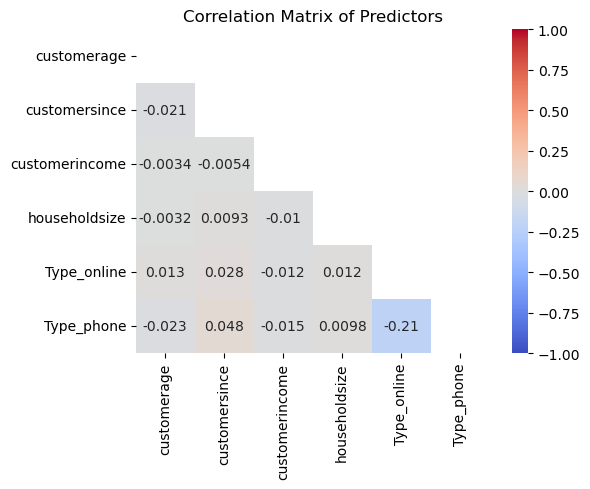


Looking at our correlation matrix I can confidently say that there is no multicollinearity issue.
All pairwise correlations are well below |0.7|. The largest I see is around -0.21 (Type_phone with some variables),
which is far from the usual 0.7–0.8 threshold where collinearity becomes a concern.


In [689]:
import seaborn as sns

df_reg = df_val.copy()

# Dummies
custtype_dummies = pd.get_dummies(df_reg['customertype'],
                                  prefix='Type',
                                  drop_first=True)
df_reg = pd.concat([df_reg, custtype_dummies], axis=1)

corr_cols = ['customervalue2023',
             'customerage',
             'customersince',
             'customerincome',
             'householdsize'] + list(custtype_dummies.columns)

corr_matrix = df_reg[corr_cols].corr()

corr_X = df_reg[corr_cols[1:]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_X,
    cmap='coolwarm',
    annot=True,
    vmin=-1,
    vmax=1,
    mask=np.triu(corr_X)
)
plt.title("Correlation Matrix of Predictors")
plt.tight_layout()
plt.show()

print("\nLooking at our correlation matrix I can confidently say that there is no multicollinearity issue.")
print("All pairwise correlations are well below |0.7|. The largest I see is around -0.21 (Type_phone with some variables),")
print("which is far from the usual 0.7–0.8 threshold where collinearity becomes a concern.")


In [691]:
df_reg['customervalue2023'] = pd.to_numeric(df_reg['customervalue2023'], errors='coerce')

for col in ['customerage', 'customerincome', 'householdsize']:
    df_reg[col] = pd.to_numeric(df_reg[col], errors='coerce')

custtype_dummies = custtype_dummies.astype(int)

print("y name:", y.name)
print("y dtype:", y.dtype)
print("\nX1_cols:", X1_cols)
print("\nX1 dtypes:\n", X1.dtypes)

y name: customervalue2023
y dtype: float64

X1_cols: ['customerage', 'customerincome', 'householdsize', 'Type_online', 'Type_phone']

X1 dtypes:
 customerage       int64
customerincome    int64
householdsize     int64
Type_online        bool
Type_phone         bool
dtype: object


In [693]:
import pandas as pd
import statsmodels.api as sm

custtype_dummies = custtype_dummies.astype(int)

X = df_reg[['customerage', 'customerincome', 'householdsize']].copy()
X[custtype_dummies.columns] = custtype_dummies

model_data = pd.concat([y, X], axis=1).dropna()
model_data = model_data.astype(float)

y = model_data['customervalue2023']
X = model_data.drop(columns=['customervalue2023'])

X_const = sm.add_constant(X)

mod_full = sm.OLS(y, X_const)
res_full = mod_full.fit()

df_reg['fittedvalues'] = res_full.fittedvalues
df_reg['residuals'] = res_full.resid

# Show summary
print(res_full.summary())

                            OLS Regression Results                            
Dep. Variable:      customervalue2023   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.219
Date:                Mon, 08 Dec 2025   Prob (F-statistic):            0.00672
Time:                        15:16:49   Log-Likelihood:                -23775.
No. Observations:                2000   AIC:                         4.756e+04
Df Residuals:                    1994   BIC:                         4.760e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -248.1272   4043.672     -0.

#### Second Model with extra variables

In [695]:
print(df_val.head())

   customerid firstname  lastname  customerage customertype  customersince  \
0           1  Coraline    Flores           23       online           2022   
1           2   Presley     Ortiz           41       online           2021   
2           3      Reid    Knight           40       online           2023   
3           4  Clarissa  Chandler           43        local           2023   
4           5     Isaac    Vaughn           23        phone           2023   

   customerincome  householdsize modecolor  customervalue2023  
0          116000              1       red            92220.0  
1          111000              1      blue             4349.0  
2           55000              1     green              210.0  
3           32000              2    orange              350.0  
4           46000              1      blue             1713.5  


In [697]:
df_reg['first_name_len'] = df_reg['firstname'].str.len()
df_reg['last_name_len'] = df_reg['lastname'].str.len()
df_reg['full_name_len'] = df_reg['first_name_len'] + df_reg['last_name_len']

df_reg['account_age'] = 2023 - df_reg['customersince']

df_reg['modecolor'] = df_reg['modecolor'].str.strip().str.lower()

mode_dummies = pd.get_dummies(df_reg['modecolor'], prefix='color', drop_first=True).astype(int)
mode_dummies = mode_dummies.loc[:, ~mode_dummies.columns.duplicated()]

df_reg = pd.concat([df_reg, mode_dummies], axis=1)

df_reg['income_x_online'] = df_reg['customerincome'] * df_reg['Type_online']
df_reg['income_x_phone']  = df_reg['customerincome'] * df_reg['Type_phone']

df_reg['age_x_online'] = df_reg['customerage'] * df_reg['Type_online']
df_reg['age_x_phone']  = df_reg['customerage'] * df_reg['Type_phone']

df_reg['hhsize_x_online'] = df_reg['householdsize'] * df_reg['Type_online']
df_reg['hhsize_x_phone']  = df_reg['householdsize'] * df_reg['Type_phone']

df_reg['account_age_x_online'] = df_reg['account_age'] * df_reg['Type_online']
df_reg['account_age_x_phone']  = df_reg['account_age'] * df_reg['Type_phone']

In [699]:
y = df_reg['customervalue2023']

X_inter = df_reg[[
    'customerage',
    'customerincome',
    'householdsize',
    'account_age',
    'first_name_len',
    'full_name_len',
    'Type_online',
    'Type_phone'
] + list(mode_dummies.columns) + [
    'income_x_online',
    'income_x_phone',
    'age_x_online',
    'age_x_phone',
    'hhsize_x_online',
    'hhsize_x_phone',
    'account_age_x_online',
    'account_age_x_phone'
]]

data_inter = pd.concat([y, X_inter], axis=1).dropna().astype(float)
y_inter = data_inter['customervalue2023']
X_inter_clean = data_inter.drop(columns=['customervalue2023'])

X_current = sm.add_constant(X_inter_clean)
threshold = 0.10

while True:
    model = sm.OLS(y_inter, X_current).fit()
    pvals = model.pvalues.drop('const')
    if all(pvals <= threshold):
        break
    # Drop variable with highest p-value above threshold
    worst_var = pvals.idxmax()
    X_current = X_current.drop(columns=[worst_var])

final_model = sm.OLS(y_inter, X_current).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:      customervalue2023   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     9.010
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.91e-18
Time:                        15:18:13   Log-Likelihood:                -23726.
No. Observations:                2000   AIC:                         4.748e+04
Df Residuals:                    1986   BIC:                         4.756e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -7725.9390   6489.053     